In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


NameError: name 'pd' is not defined

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "https://raw.githubusercontent.com/yannie28/Global-Superstore/master/Global_Superstore%28CSV%29.csv"
)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 1000
Columns: 24


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


In [5]:
# Basic dataset inspection

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1000, 24)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Postal Code', 'City', 'State', 'Country', 'Region', 'Market', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost', 'Order Priority']

Missing Values:
Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,1000.000000,194.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,25079.328000,53966.170103,1710.971470,5.55800,0.092840,288.920440,272.384897
std,12897.726632,33734.306466,1259.239238,2.71846,0.148666,574.504782,176.160716
min,58.000000,2920.000000,1.910000,1.00000,0.000000,-3059.820000,1.070000
25%,15118.750000,19134.000000,826.907500,4.00000,0.000000,10.037500,209.827500
50%,25084.500000,60564.000000,1585.115000,5.00000,0.000000,190.685000,258.897500
75%,34524.000000,88187.500000,2477.812500,7.00000,0.150000,518.872500,351.070250
max,51284.000000,98198.000000,9892.740000,14.00000,0.800000,4946.370000,923.630000



Data Types:
Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID        object
Customer Name      object
Segment            object
Postal Code       float64
City               object
State              object
Country            object
Region             object
Market             object
Product ID         object
Category           object
Sub-Category       object
Product Name       object
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority     object
dtype: object


In [6]:

# Clean the dataset

# Remove duplicate rows
df = df.drop_duplicates()

# Convert date column
if "Order Date" in df.columns:
    df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

# Convert numerical columns
numeric_columns = ["Sales", "Profit", "Quantity", "Discount"]

for column in numeric_columns:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

# Check missing values after cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDataset shape after cleaning:", df.shape)

print("\nCleaning completed successfully!")

Missing values after cleaning:
Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

Dataset shape after cleaning: (1000, 24)

Cleaning completed successfully!


In [7]:
# Key business questions

print("KEY QUESTIONS FOR EDA")
print("1. Which product categories generate the highest sales?")
print("2. Which regions generate the highest profit?")
print("3. How does discount affect profit?")
print("4. What is the relationship between sales and profit?")
print("5. Which categories have unusually high or low profit?")
print("6. How do sales change over time?")

KEY QUESTIONS FOR EDA
1. Which product categories generate the highest sales?
2. Which regions generate the highest profit?
3. How does discount affect profit?
4. What is the relationship between sales and profit?
5. Which categories have unusually high or low profit?
6. How do sales change over time?


,Sales,Profit
Category,,
Technology,756983.02,145068.68
Furniture,601492.31,82188.95
Office Supplies,352496.14,61662.81


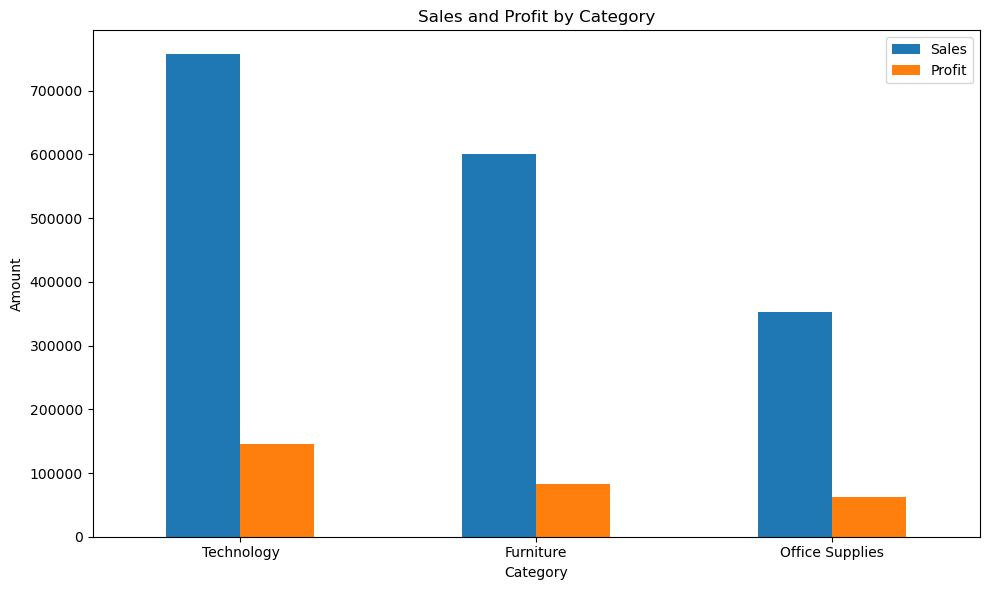

In [8]:
# Sales and profit by category

if "Category" in df.columns:
    category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values(
        "Sales", ascending=False
    )

    display(category_analysis)

    category_analysis.plot(kind="bar", figsize=(10, 6))
    plt.title("Sales and Profit by Category")
    plt.xlabel("Category")
    plt.ylabel("Amount")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

,Sales,Profit
Region,,
Western Europe,259576.28,32783.40
Oceania,220809.08,33777.56
Southern Asia,205466.26,37536.60
Eastern Asia,193590.60,37911.16
Southeastern Asia,147337.60,10561.80
Central America,140966.21,21741.95
Northern Europe,103888.63,23552.73
Southern Europe,94441.11,20557.50
South America,64550.54,7723.58


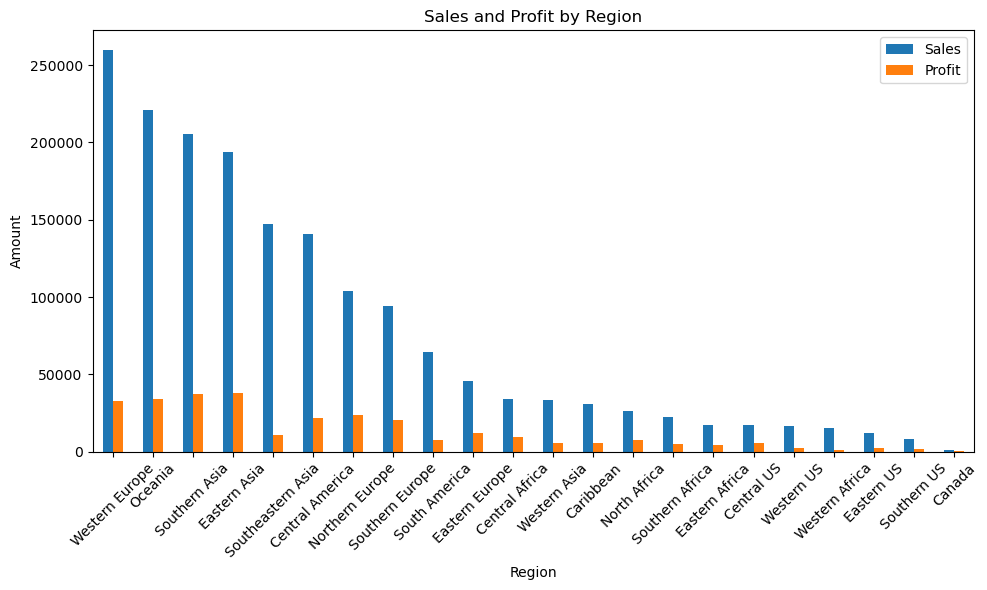

In [9]:
# Regional Sales and Profit Analysis

region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values(
    "Sales", ascending=False
)

display(region_analysis)

# Visualize regional performance
region_analysis.plot(kind="bar", figsize=(10, 6))

plt.title("Sales and Profit by Region")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Correlation between Discount and Profit:
-0.5051903486407421


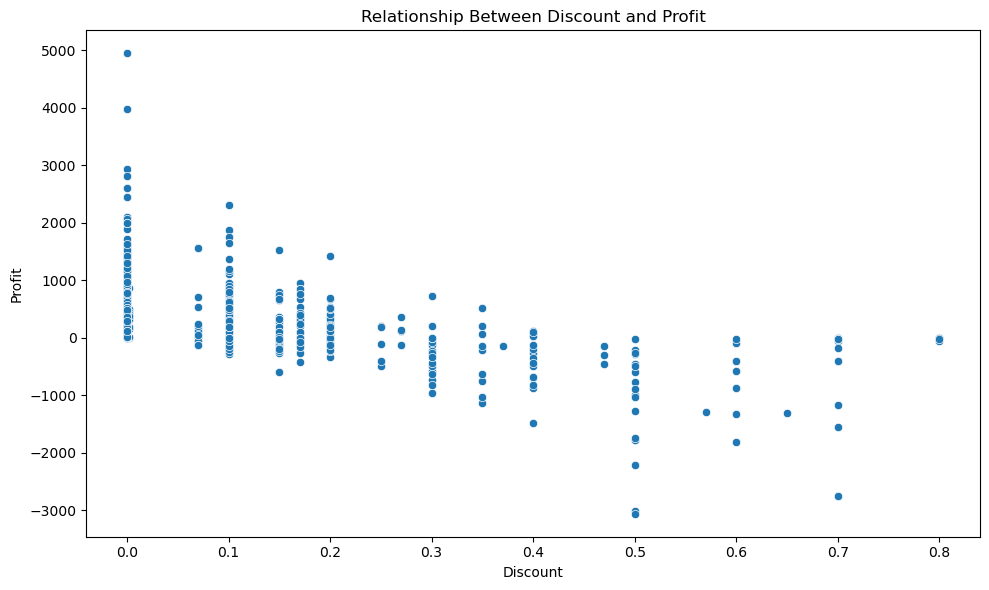

In [10]:
# Discount vs Profit Analysis

discount_profit = df[["Discount", "Profit"]].dropna()

print("Correlation between Discount and Profit:")
print(discount_profit["Discount"].corr(discount_profit["Profit"]))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=discount_profit, x="Discount", y="Profit")

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

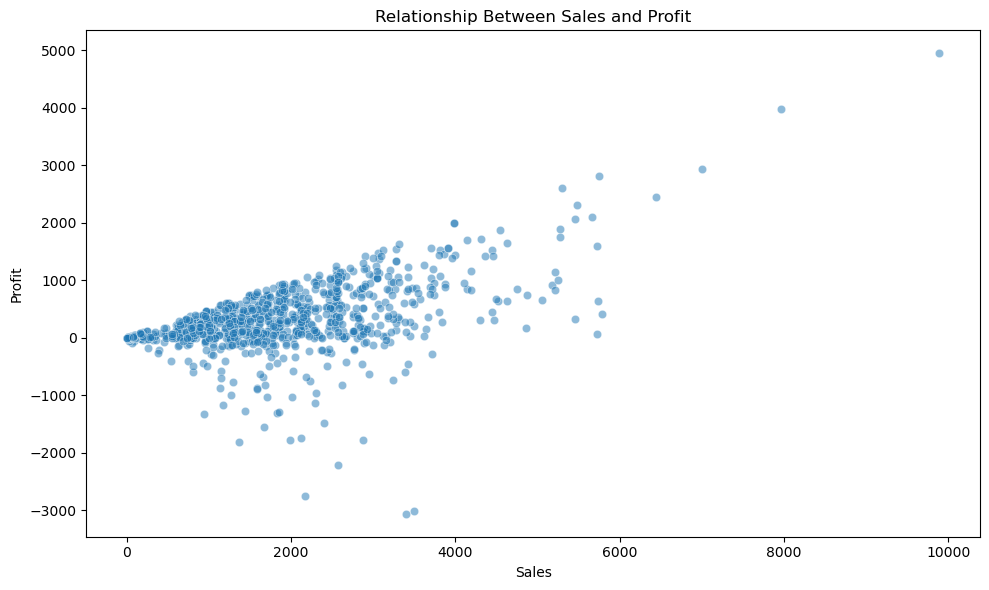

In [11]:
# Sales vs Profit Relationship

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.5
)

plt.title("Relationship Between Sales and Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

C:\Users\sunan\AppData\Local\Temp\ipykernel_11584\3985044942.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Sales"]


Order Date
2012-01-31    11627.23
2012-02-29    20635.28
2012-03-31    13516.89
2012-04-30     7222.25
2012-05-31    21908.53
Freq: ME, Name: Sales, dtype: float64

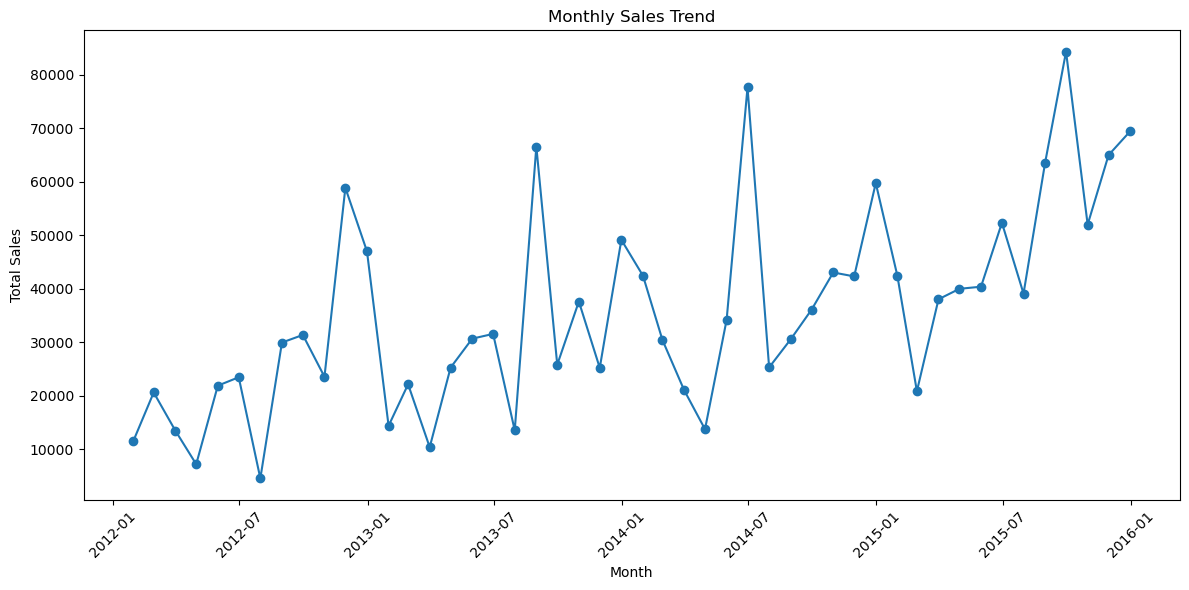

In [12]:
# Monthly Sales Trend

df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

monthly_sales = (
    df.dropna(subset=["Order Date"])
      .set_index("Order Date")
      .resample("M")["Sales"]
      .sum()
)

display(monthly_sales.head())

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Profit Anomaly Detection using IQR

Q1 = df["Profit"].quantile(0.25)
Q3 = df["Profit"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

anomalies = df[
    (df["Profit"] < lower_limit) |
    (df["Profit"] > upper_limit)
]

print("Lower Profit Limit:", lower_limit)
print("Upper Profit Limit:", upper_limit)
print("Number of Profit Anomalies:", len(anomalies))

display(anomalies[["Profit", "Sales", "Discount"]].head(10))

Lower Profit Limit: -753.2149999999998
Upper Profit Limit: 1282.1249999999998
Number of Profit Anomalies: 67


,Profit,Sales,Discount
17,3979.08,7958.58,0.00
23,1898.40,5273.70,0.00
27,1364.24,3069.74,0.10
38,1697.67,4141.02,0.00
42,2097.03,5667.87,0.00
72,1523.52,3808.80,0.00
81,2597.28,5301.24,0.00
100,1465.20,3856.14,0.00
105,1517.71,4448.83,0.15
109,-2211.17,2570.87,0.50


In [14]:
# Hypothesis Testing

from scipy.stats import pearsonr

test_data = df[["Discount", "Profit"]].dropna()

correlation, p_value = pearsonr(
    test_data["Discount"],
    test_data["Profit"]
)

print("Correlation:", correlation)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: The relationship is statistically significant.")
else:
    print("Result: The relationship is not statistically significant.")

Correlation: -0.5051903486407422
P-value: 6.923354655084397e-66
Result: The relationship is statistically significant.


In [15]:
# Final EDA Insights

print("========== FINAL EDA INSIGHTS ==========")

# Best category
if "Category" in df.columns:
    best_category = df.groupby("Category")["Sales"].sum().idxmax()
    print("1. Highest-sales category:", best_category)

# Best region
if "Region" in df.columns:
    best_region = df.groupby("Region")["Profit"].sum().idxmax()
    print("2. Most profitable region:", best_region)

# Average values
print("3. Average Sales:", round(df["Sales"].mean(), 2))
print("4. Average Profit:", round(df["Profit"].mean(), 2))
print("5. Average Discount:", round(df["Discount"].mean(), 2))

# Correlation
correlation = df["Discount"].corr(df["Profit"])
print("6. Discount-Profit correlation:", round(correlation, 3))

# Anomalies
print("7. Number of profit anomalies:", len(anomalies))

print("\nEDA COMPLETED SUCCESSFULLY!")

========== FINAL EDA INSIGHTS ==========
1. Highest-sales category: Technology
2. Most profitable region: Eastern Asia
3. Average Sales: 1710.97
4. Average Profit: 288.92
5. Average Discount: 0.09
6. Discount-Profit correlation: -0.505
7. Number of profit anomalies: 67

EDA COMPLETED SUCCESSFULLY!


In [18]:
print("""
CONCLUSION

The Exploratory Data Analysis provided useful insights into the sales dataset.

1. Sales performance was compared across different product categories.
2. Regional sales and profitability were analyzed.
3. The relationship between discount and profit was investigated.
4. Sales trends over time were examined to identify changes in business performance.
5. Statistical measures were used to understand important variables.
6. Profit anomalies were identified using the Interquartile Range (IQR) method.
7. Correlation and hypothesis testing were used to evaluate relationships between variables.

Overall, the analysis demonstrates how exploratory data analysis can be used to identify
trends, relationships, anomalies, and potential business insights from raw data.
""")


CONCLUSION

The Exploratory Data Analysis provided useful insights into the sales dataset.

1. Sales performance was compared across different product categories.
2. Regional sales and profitability were analyzed.
3. The relationship between discount and profit was investigated.
4. Sales trends over time were examined to identify changes in business performance.
5. Statistical measures were used to understand important variables.
6. Profit anomalies were identified using the Interquartile Range (IQR) method.
7. Correlation and hypothesis testing were used to evaluate relationships between variables.

Overall, the analysis demonstrates how exploratory data analysis can be used to identify
trends, relationships, anomalies, and potential business insights from raw data.

